# 300 · 오픈웨이트 모델 해부 — 열어보고 재기

**GPU 필요** (Colab: 런타임 > 런타임 유형 변경 > T4)

## 이 노트북에서 하는 일
1. 같은 모델을 **fp16과 4bit로 각각 로드**해 VRAM을 실측 비교한다
2. `model.config`를 6교시 슬라이드(RoPE·RMSNorm·GQA)와 **1:1로 대조**한다
3. 한 스텝 forward의 **로짓 상위 10개**를 보고, temperature가 분포를 어떻게 바꾸는지 관찰한다
4. greedy / top-p / seed 고정으로 생성하고 **재현성**을 확인한다
5. **`use_cache` 유무의 지연 차이**를 재고, KV 캐시 메모리를 **계산식과 실측으로 대조**한다
6. 어텐션 가중치 히트맵을 그린다

> 여기서 모델 로드·토크나이저 왕복·생성 제어에
> 익숙해지지 않으면 `420`에서 무엇이 잘못되었는지 판단할 수 없다.

In [1]:
# --- 패키지 설치 (Colab) ---
# 설치 후 "런타임 다시 시작" 안내가 나오면 재시작하고, 다음 셀부터 이어서 실행한다.
!pip install -q transformers==4.57.1 datasets==4.0.0 accelerate==1.10.1 \
    peft==0.17.1 trl==0.23.0 bitsandbytes==0.47.0 tiktoken==0.11.0
!apt-get install -y fonts-nanum -qq > /dev/null   # matplotlib 한글 폰트

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.7/564.7 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
# --- 저장소 클론 및 루트 이동 (Colab) ---
from pathlib import Path

if not Path("common/config.py").exists():
    !git clone -q https://github.com/ironmanciti/LLM_FineTuning_Lecture.git
    %cd LLM_FineTuning_Lecture
print("저장소 루트:", Path.cwd())

from common import config as C, env, artifacts as art
env.set_seed(C.SEED)

/content/LLM_FineTuning_Lecture
저장소 루트: /content/LLM_FineTuning_Lecture


42

In [ ]:
# --- Google Drive 연결: artifacts/ 영속화 (Colab) ---
# 노트북마다 런타임(VM)이 다르므로, 산출물을 Drive에 두어야 다음 노트북에서 읽을 수 있다.
import shutil
from pathlib import Path

try:
    from google.colab import drive  # Colab이 아니면 ImportError

    drive.mount("/content/drive")

    DRIVE_ART = Path("/content/drive/MyDrive/LLM_FineTuning_Lecture/artifacts")
    DRIVE_ART.mkdir(parents=True, exist_ok=True)

    local_art = Path("artifacts")
    if not local_art.is_symlink():
        if local_art.exists():  # 이미 로컬에 쓴 결과가 있으면 Drive로 이관
            shutil.copytree(local_art, DRIVE_ART, dirs_exist_ok=True)
            shutil.rmtree(local_art)
        local_art.symlink_to(DRIVE_ART)
    print("artifacts ->", local_art.resolve())
except ImportError:
    print("Colab이 아니므로 로컬 artifacts/ 를 그대로 사용합니다.")


In [3]:
info = env.print_env()
art.save_json(art.env_path(), info.to_dict())

assert info.cuda_available, (
    "GPU가 없습니다. Colab에서 [런타임 > 런타임 유형 변경 > T4 GPU]를 선택하고 다시 실행하십시오.\n"
    "GPU를 쓸 수 없으면 010·020·410·450만 진행하고, 이 노트북의 결과는 "
    "artifacts/reference/ 의 강사 사전 실행 결과로 대체합니다."
)

Python 3.12.13  |  torch 2.11.0+cu128
GPU            : Tesla T4  (14.56 GB)
bf16 지원      : True
권장 dtype     : bfloat16
attention 구현 : sdpa
  [주의] T4는 FlashAttention을 지원하지 않습니다. attn_implementation='sdpa'(또는 'eager')를 사용합니다.


---
## 1. fp16 vs 4bit — 메모리는 줄고 연산량은 줄지 않는다

같은 모델을 두 방식으로 로드해 VRAM을 잰다. 4bit 로드는 **학습을 T4에 태우기 위한 것**이고
(2일차 §3.8), 배포용 양자화(GGUF·AWQ)는 다른 이야기다 — 후속 과정 소관.

In [4]:
import time, torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_ID = C.MODEL_ID
print("대상 모델:", MODEL_ID)

tok = AutoTokenizer.from_pretrained(MODEL_ID)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
print("vocab:", f"{tok.vocab_size:,}", "| eos:", repr(tok.eos_token))

대상 모델: Qwen/Qwen2.5-0.5B-Instruct


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

vocab: 151,643 | eos: '<|im_end|>'


In [5]:
DTYPE = env.pick_dtype()
print("이 런타임의 dtype:", DTYPE)

# (A) 16비트 로드
with env.vram_probe("fp16/bf16 로드") as p16:
    model16 = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, torch_dtype=DTYPE, device_map={"": 0},
        attn_implementation=info.attn_implementation,
    )
    model16.eval()
vram_16 = p16.result

이 런타임의 dtype: torch.bfloat16


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

[VRAM] fp16/bf16 로드: +0.92 GB (피크 0.92 GB)


In [6]:
n_total = sum(p.numel() for p in model16.parameters())
n_train = sum(p.numel() for p in model16.parameters() if p.requires_grad)
bytes_per = 2 if DTYPE in (torch.float16, torch.bfloat16) else 4
print(f"파라미터 수      : {n_total/1e9:.3f}B ({n_total:,})")
print(f"이론 가중치 크기 : {n_total*bytes_per/1024**3:.2f} GB  ({bytes_per}바이트/파라미터)")
print(f"실측 VRAM 증가분 : {vram_16['delta_gb']} GB")
print("\n※ 실측이 이론보다 큰 것은 버퍼·정렬·CUDA 컨텍스트 때문이다.")
print("   §3.6-7 VRAM 예산표를 이론값으로만 만들면 20~30% 어긋난다.")

파라미터 수      : 0.494B (494,032,768)
이론 가중치 크기 : 0.92 GB  (2바이트/파라미터)
실측 VRAM 증가분 : 0.92 GB

※ 실측이 이론보다 큰 것은 버퍼·정렬·CUDA 컨텍스트 때문이다.
   §3.6-7 VRAM 예산표를 이론값으로만 만들면 20~30% 어긋난다.


In [7]:
# 16비트 모델은 잠시 내려두고 4bit로 다시 로드한다
del model16
torch.cuda.empty_cache()

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",            # 정규분포에 맞춘 4bit 표현 (§3.8-2)
    bnb_4bit_use_double_quant=True,       # 양자화 상수를 다시 양자화 (§3.8-2)
    bnb_4bit_compute_dtype=DTYPE,         # T4는 bf16이 없으므로 fp16이 들어간다
)
print("BitsAndBytesConfig:")
for k in ["load_in_4bit", "bnb_4bit_quant_type", "bnb_4bit_use_double_quant", "bnb_4bit_compute_dtype"]:
    print(f"  {k:<32}{getattr(bnb, k)}")

with env.vram_probe("4bit(NF4) 로드") as p4:
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, quantization_config=bnb, device_map={"": 0},
        attn_implementation=info.attn_implementation,
    )
    model.eval()
vram_4 = p4.result

BitsAndBytesConfig:
  load_in_4bit                    True
  bnb_4bit_quant_type             nf4
  bnb_4bit_use_double_quant       True
  bnb_4bit_compute_dtype          torch.bfloat16


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:212: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[VRAM] 4bit(NF4) 로드: +0.426 GB (피크 0.507 GB)


In [8]:
import pandas as pd
cmp = pd.DataFrame([
    {"방식": f"{DTYPE}".replace("torch.", ""), "VRAM(GB)": vram_16["delta_gb"],
     "이론 가중치(GB)": round(n_total * 2 / 1024**3, 2)},
    {"방식": "4bit NF4 + 이중양자화", "VRAM(GB)": vram_4["delta_gb"],
     "이론 가중치(GB)": round(n_total * 0.5 / 1024**3, 2)},
])
cmp["절감률"] = (100 * (1 - cmp["VRAM(GB)"] / cmp["VRAM(GB)"].iloc[0])).round(1).astype(str) + "%"
display(cmp)
print("확인: 4bit가 메모리를 줄인다. 하지만 다음 셀에서 보듯 **속도는 빨라지지 않는다** —")
print("      순전파마다 dequantize가 일어나기 때문이다(§3.8-1).")

,방식,VRAM(GB),이론 가중치(GB),절감률
0,bfloat16,0.920,0.92,0.0%
1,4bit NF4 + 이중양자화,0.426,0.23,53.7%


확인: 4bit가 메모리를 줄인다. 하지만 다음 셀에서 보듯 **속도는 빨라지지 않는다** —
      순전파마다 dequantize가 일어나기 때문이다(§3.8-1).


---
## 2. `config`를 6교시 슬라이드와 대조하기

6교시에서 배운 현대 디코더 구성요소가 config의 어느 필드로 나타나는지 확인한다.

In [9]:
cfg = model.config
fields = [
    ("hidden_size",              "d_model — 잔차 스트림의 폭"),
    ("num_hidden_layers",        "블록 반복 횟수"),
    ("num_attention_heads",      "쿼리 헤드 수"),
    ("num_key_value_heads",      "★ KV 헤드 수 — 쿼리보다 적으면 GQA (§3.2-4)"),
    ("intermediate_size",        "FFN 확장 폭"),
    ("hidden_act",               "★ 활성함수 — silu = SwiGLU 계열 (§3.2-2)"),
    ("rms_norm_eps",             "★ 이 필드가 있으면 RMSNorm (§3.2-2)"),
    ("rope_theta",               "★ RoPE 기저 — 컨텍스트 확장의 손잡이 (§3.2-3)"),
    ("max_position_embeddings",  "학습된 최대 컨텍스트"),
    ("vocab_size",               "어휘 크기 — 임베딩·LM head 크기를 정한다"),
    ("tie_word_embeddings",      "★ weight tying — 입력 임베딩과 LM head 공유 (§3.2, 슬라이드 57)"),
]
print(f"{'필드':<26}{'값':<16}의미")
print("-" * 100)
for f, desc in fields:
    v = getattr(cfg, f, "(없음)")
    print(f"{f:<26}{str(v):<16}{desc}")

필드                        값               의미
----------------------------------------------------------------------------------------------------
hidden_size               896             d_model — 잔차 스트림의 폭
num_hidden_layers         24              블록 반복 횟수
num_attention_heads       14              쿼리 헤드 수
num_key_value_heads       2               ★ KV 헤드 수 — 쿼리보다 적으면 GQA (§3.2-4)
intermediate_size         4864            FFN 확장 폭
hidden_act                silu            ★ 활성함수 — silu = SwiGLU 계열 (§3.2-2)
rms_norm_eps              1e-06           ★ 이 필드가 있으면 RMSNorm (§3.2-2)
rope_theta                1000000.0       ★ RoPE 기저 — 컨텍스트 확장의 손잡이 (§3.2-3)
max_position_embeddings   32768           학습된 최대 컨텍스트
vocab_size                151936          어휘 크기 — 임베딩·LM head 크기를 정한다
tie_word_embeddings       True            ★ weight tying — 입력 임베딩과 LM head 공유 (§3.2, 슬라이드 57)


In [10]:
# GQA 확인과 KV 캐시 절감량 계산
nq = cfg.num_attention_heads
nkv = getattr(cfg, "num_key_value_heads", nq)
head_dim = cfg.hidden_size // nq
mode = "MHA (헤드마다 K·V)" if nkv == nq else ("MQA (전부 공유)" if nkv == 1 else f"GQA (그룹 {nq//nkv}:1)")

print(f"쿼리 헤드 {nq} / KV 헤드 {nkv} / head_dim {head_dim}  ->  {mode}")
print(f"MHA 대비 KV 캐시 절감: {100*(1 - nkv/nq):.1f}%\n")

print(f"{'컨텍스트':>10}{'KV캐시(계산식)':>18}{'MHA였다면':>14}")
for L in [512, 1024, 2048, 4096, 8192]:
    gqa = env.kv_cache_gb(cfg.num_hidden_layers, nkv, head_dim, L)
    mha = env.kv_cache_gb(cfg.num_hidden_layers, nq, head_dim, L)
    print(f"{L:>10}{gqa:>17.4f}G{mha:>13.4f}G")
print("\n계산식: 2(K,V) x layers x kv_heads x head_dim x seq_len x 2바이트")

쿼리 헤드 14 / KV 헤드 2 / head_dim 64  ->  GQA (그룹 7:1)
MHA 대비 KV 캐시 절감: 85.7%

      컨텍스트         KV캐시(계산식)        MHA였다면
       512           0.0059G       0.0410G
      1024           0.0117G       0.0820G
      2048           0.0234G       0.1641G
      4096           0.0469G       0.3281G
      8192           0.0938G       0.6562G

계산식: 2(K,V) x layers x kv_heads x head_dim x seq_len x 2바이트


> **확인 질문.** 이 모델이 GQA를 쓰지 않았다면 컨텍스트 8192에서 KV 캐시가 몇 배 커지는가?
> T4 16GB에서 그 차이가 배치 크기에 어떤 제약을 만드는가?

---
## 3. 로짓 → 확률 → 토큰

LM head가 내놓는 것은 **어휘 크기만큼의 실수 벡터(로짓)**다. 그 뒤에 일어나는 일이
디코딩 파라미터의 정체다.

In [11]:
import torch.nn.functional as F
from common import chat

msgs = chat.build_messages("대한민국에서 가장 높은 산의 이름은", system="간결하게 답하십시오.")
prompt = chat.render_prompt(tok, msgs)
inputs = tok(prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    out = model(**inputs)
logits = out.logits[0, -1]          # 마지막 위치 = 다음 토큰 예측
print("로짓 shape:", tuple(out.logits.shape), "-> (배치, 시퀀스, vocab)")
print("마지막 위치 로짓:", tuple(logits.shape))
print(f"로짓 범위: {logits.min().item():.2f} ~ {logits.max().item():.2f}")

로짓 shape: (1, 35, 151936) -> (배치, 시퀀스, vocab)
마지막 위치 로짓: (151936,)
로짓 범위: -17.95 ~ 16.45


In [12]:
def top_table(logits, temperature=1.0, k=10):
    z = logits / temperature if temperature and temperature > 0 else logits
    probs = F.softmax(z.float(), dim=-1)
    v, i = probs.topk(k)
    return [{"토큰": repr(tok.decode([idx])), "확률": round(float(pv), 4)}
            for pv, idx in zip(v.tolist(), i.tolist())]

for T in [0.1, 0.7, 1.0, 1.5]:
    rows = top_table(logits, T, k=6)
    top1 = rows[0]
    mass = sum(r["확률"] for r in rows)
    print(f"T={T:<4} 1위 {top1['토큰']:<12} p={top1['확률']:.4f}   상위6 확률합 {mass:.4f}")

T=0.1  1위 '대'          p=1.0000   상위6 확률합 1.0000
T=0.7  1위 '대'          p=0.8769   상위6 확률합 0.9732
T=1.0  1위 '대'          p=0.5836   상위6 확률합 0.7636
T=1.5  1위 '대'          p=0.1072   상위6 확률합 0.1854


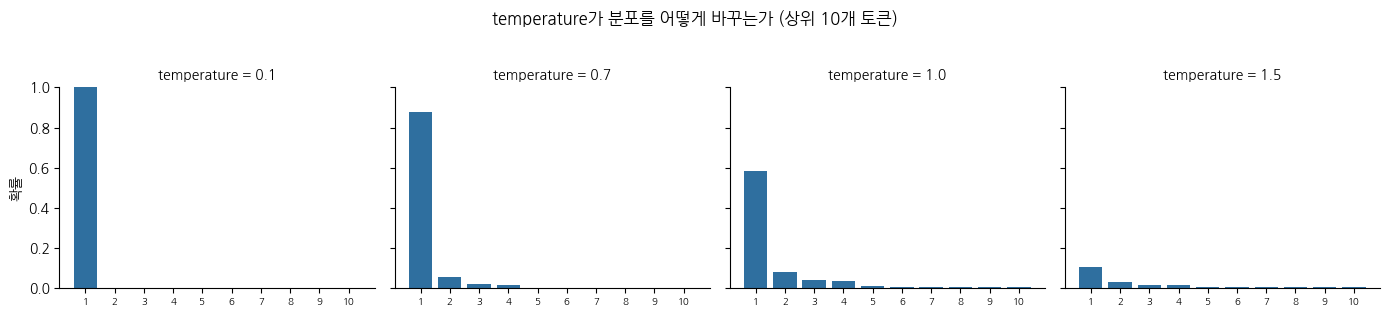

T가 작으면 1위에 확률이 몰리고(=greedy에 가까워짐), 크면 평평해진다.
top_p / top_k 는 이 분포를 **자른 뒤** 다시 정규화하는 것이다.


In [13]:
import matplotlib.pyplot as plt, matplotlib
matplotlib.font_manager.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
for ax, T in zip(axes, [0.1, 0.7, 1.0, 1.5]):
    rows = top_table(logits, T, k=10)
    ax.bar(range(10), [r["확률"] for r in rows], color="#2f6f9f")
    ax.set_title(f"temperature = {T}", fontsize=10)
    ax.set_xticks(range(10)); ax.set_xticklabels(range(1, 11), fontsize=7)
    ax.set_ylim(0, 1); ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("확률")
fig.suptitle("temperature가 분포를 어떻게 바꾸는가 (상위 10개 토큰)", y=1.04)
plt.tight_layout(); plt.show()

print("T가 작으면 1위에 확률이 몰리고(=greedy에 가까워짐), 크면 평평해진다.")
print("top_p / top_k 는 이 분포를 **자른 뒤** 다시 정규화하는 것이다.")

---
## 4. 재현성 — "온도 0이면 항상 같은 답"이 참이 아닌 이유

In [14]:
def gen(prompt, **kw):
    ins = tok(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        o = model.generate(**ins, pad_token_id=tok.pad_token_id, **kw)
    return tok.decode(o[0][ins["input_ids"].shape[1]:], skip_special_tokens=True).strip()

print("── greedy (do_sample=False) 3회")
for i in range(3):
    print(f"   {i+1}: {gen(prompt, max_new_tokens=40, do_sample=False)!r}")

print("\n── sampling, seed 고정 없음 3회")
for i in range(3):
    print(f"   {i+1}: {gen(prompt, max_new_tokens=40, do_sample=True, temperature=0.9, top_p=0.9)!r}")

print("\n── sampling, 매번 seed 고정 3회")
for i in range(3):
    env.set_seed(C.SEED)
    print(f"   {i+1}: {gen(prompt, max_new_tokens=40, do_sample=True, temperature=0.9, top_p=0.9)!r}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


── greedy (do_sample=False) 3회


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


   1: "대한민국에서 가장 높은 산은 '산호산'입니다. 이 산은 대한민국의 수도인 서울시에 위치하고 있으며, 19"
   2: "대한민국에서 가장 높은 산은 '산호산'입니다. 이 산은 대한민국의 수도인 서울시에 위치하고 있으며, 19"
   3: "대한민국에서 가장 높은 산은 '산호산'입니다. 이 산은 대한민국의 수도인 서울시에 위치하고 있으며, 19"

── sampling, seed 고정 없음 3회
   1: '대한민국에서 가장 높은 산 중 하나는 대구산입니다.\n- 대구산 (Gwangyang Mountain): 가장 높은 산 중 한 명'
   2: '미안합니다, 제가 한국에 있는 대한민국에서 가장 높은 산을 도와드릴 수 없습니다. 저는 국제적 기반을 가지고 있으며 모든 국가가 다양한'
   3: '대한민국에서 가장 높은 산의 이름은 울산입니다.'

── sampling, 매번 seed 고정 3회
   1: '대한민국에서 가장 높은 산 중 하나는 대구산입니다.\n- 대구산 (Gwangyang Mountain): 가장 높은 산 중 한 명'
   2: '대한민국에서 가장 높은 산 중 하나는 대구산입니다.\n- 대구산 (Gwangyang Mountain): 가장 높은 산 중 한 명'
   3: '대한민국에서 가장 높은 산 중 하나는 대구산입니다.\n- 대구산 (Gwangyang Mountain): 가장 높은 산 중 한 명'


### 관찰

- greedy는 같은 입력에서 같은 출력을 낸다 — **같은 배치 구성·같은 dtype·같은 커널일 때만.**
  배치 크기를 바꾸면 부동소수점 누적 순서가 달라져 결과가 미세하게 달라질 수 있다.
- ** `do_sample=False`로 고정하는 이유가 여기다**(§3.12-1 '평가의 최소 요건').
  샘플링으로 채점하면 같은 모델을 두 번 재도 점수가 다르게 나온다.

---
## 5. KV 캐시 — prefill과 decode

`use_cache=False`로 두면 매 스텝 전체 시퀀스를 다시 계산한다. 얼마나 느려지는가?

In [15]:
def timed(prompt, n_new, use_cache):
    ins = tok(prompt, return_tensors="pt").to(model.device)
    torch.cuda.synchronize(); env.vram_reset()
    t0 = time.perf_counter()
    with torch.no_grad():
        model.generate(**ins, max_new_tokens=n_new, do_sample=False,
                       use_cache=use_cache, pad_token_id=tok.pad_token_id)
    torch.cuda.synchronize()
    dt = time.perf_counter() - t0
    return {"use_cache": use_cache, "초": round(dt, 3),
            "토큰/초": round(n_new / dt, 1), "피크VRAM(GB)": env.vram_gb()["peak_gb"]}

long_prompt = chat.render_prompt(tok, chat.build_messages(
    ("다음 문장을 요약하십시오.\n" + "인공지능 교육과정 개편의 배경과 목표는 다음과 같습니다. ") * 20
))
rows = [timed(long_prompt, 64, True), timed(long_prompt, 64, False)]
display(pd.DataFrame(rows))
speedup = rows[1]["초"] / max(rows[0]["초"], 1e-9)
print(f"\nKV 캐시로 {speedup:.1f}배 빠르다. 캐시가 없으면 매 스텝 O(n²) 재계산이 일어난다.")

,use_cache,초,토큰/초,피크VRAM(GB)
0,True,5.708,11.2,0.504
1,False,15.834,4.0,0.510



KV 캐시로 2.8배 빠르다. 캐시가 없으면 매 스텝 O(n²) 재계산이 일어난다.


In [16]:
# TTFT(첫 토큰까지)와 TPOT(이후 토큰당) 분리 측정 — prefill vs decode (§3.3-3)
def ttft_tpot(prompt, n_new=48):
    ins = tok(prompt, return_tensors="pt").to(model.device)
    torch.cuda.synchronize(); t0 = time.perf_counter()
    with torch.no_grad():
        model.generate(**ins, max_new_tokens=1, do_sample=False, pad_token_id=tok.pad_token_id)
    torch.cuda.synchronize(); ttft = time.perf_counter() - t0
    torch.cuda.synchronize(); t1 = time.perf_counter()
    with torch.no_grad():
        model.generate(**ins, max_new_tokens=n_new, do_sample=False, pad_token_id=tok.pad_token_id)
    torch.cuda.synchronize(); total = time.perf_counter() - t1
    tpot = (total - ttft) / max(n_new - 1, 1)
    return {"프롬프트 토큰": ins["input_ids"].shape[1],
            "TTFT(ms)": round(1000 * ttft, 1), "TPOT(ms/토큰)": round(1000 * tpot, 2)}

short = chat.render_prompt(tok, chat.build_messages("안녕하세요."))
display(pd.DataFrame([ttft_tpot(short), ttft_tpot(long_prompt)]))
print("긴 프롬프트는 TTFT가 커지고(prefill이 연산 집약), TPOT는 크게 안 변한다(decode는 메모리 대역 집약).")

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


,프롬프트 토큰,TTFT(ms),TPOT(ms/토큰)
0,33,106.9,21.06
1,570,233.3,69.26


긴 프롬프트는 TTFT가 커지고(prefill이 연산 집약), TPOT는 크게 안 변한다(decode는 메모리 대역 집약).


In [17]:
# KV 캐시 실측 vs 계산식 대조
recs = []
for L in [256, 512, 1024]:
    ids = torch.randint(0, tok.vocab_size, (1, L)).to(model.device)
    env.vram_reset(); before = env.vram_gb()["allocated_gb"]
    with torch.no_grad():
        o = model(ids, use_cache=True)
    after = env.vram_gb()["peak_gb"]
    recs.append({"컨텍스트": L,
                 "계산식(GB)": env.kv_cache_gb(cfg.num_hidden_layers, nkv, head_dim, L),
                 "실측 피크 증가(GB)": round(after - before, 4)})
    del o; torch.cuda.empty_cache()
display(pd.DataFrame(recs))
print("실측이 더 큰 것은 로짓 텐서(seq x vocab)와 중간 활성값이 함께 잡히기 때문이다.")
print("계산식은 하한이고, 예산은 여유를 두고 잡아야 한다 — §3.8-4 예산표의 근거.")

,컨텍스트,계산식(GB),실측 피크 증가(GB)
0,256,0.0029,0.075
1,512,0.0059,0.151
2,1024,0.0117,0.303


실측이 더 큰 것은 로짓 텐서(seq x vocab)와 중간 활성값이 함께 잡히기 때문이다.
계산식은 하한이고, 예산은 여유를 두고 잡아야 한다 — §3.8-4 예산표의 근거.


---
## 6. 어텐션 히트맵

1일차 5교시에서 `softmax(QKᵀ/√d)V` 한 줄로 압축했던 것을 눈으로 본다.
(행렬 연산을 직접 구현하는 것은 「Python과 Pytorch 딥러닝 입문」 과정 소관이다.)

/tmp/ipykernel_502/968684857.py:26: UserWarning: Glyph 236 (\N{LATIN SMALL LETTER I WITH GRAVE}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_502/968684857.py:26: UserWarning: Glyph 318 (\N{LATIN SMALL LETTER L WITH CARON}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_502/968684857.py:26: UserWarning: Glyph 316 (\N{LATIN SMALL LETTER L WITH CEDILLA}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_502/968684857.py:26: UserWarning: Glyph 290 (\N{LATIN CAPITAL LETTER G WITH CEDILLA}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_502/968684857.py:26: UserWarning: Glyph 302 (\N{LATIN CAPITAL LETTER I WITH OGONEK}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_502/968684857.py:26: UserWarning: Glyph 311 (\N{LATIN SMALL LETTER K WITH CEDILLA}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()
/tmp/

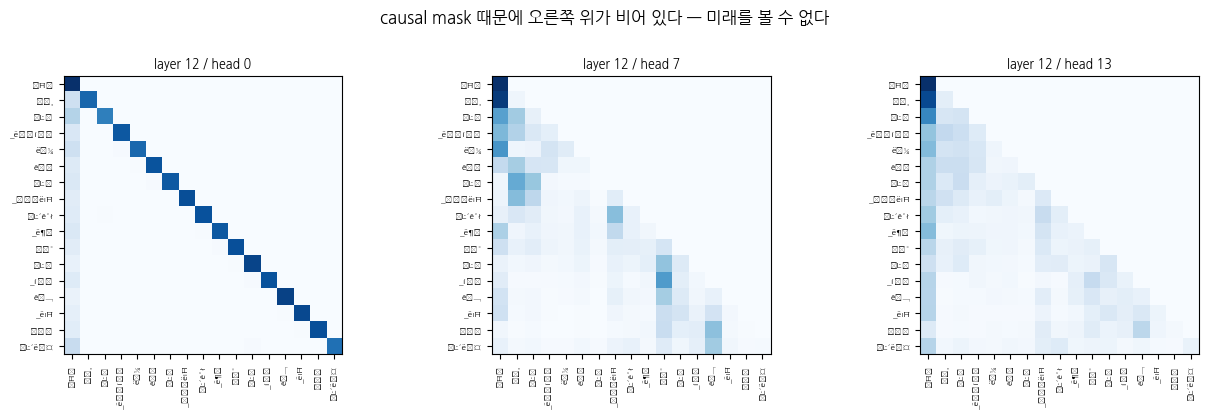

In [18]:
import numpy as np

# sdpa/flash 구현은 attention 가중치를 반환하지 않으므로 잠시 eager로 전환한다
model.set_attn_implementation("eager")

sent = "서울은 대한민국의 수도이고 부산은 항구 도시이다"
ins = tok(sent, return_tensors="pt").to(model.device)
with torch.no_grad():
    o = model(**ins, output_attentions=True)

model.set_attn_implementation(info.attn_implementation)   # 원래 구현으로 복원

toks = tok.convert_ids_to_tokens(ins["input_ids"][0])
layer = len(o.attentions) // 2          # 중간 층
attn = o.attentions[layer][0].float().cpu().numpy()   # (heads, T, T)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, h in zip(axes, [0, attn.shape[0] // 2, attn.shape[0] - 1]):
    ax.imshow(attn[h], cmap="Blues", vmin=0, vmax=attn[h].max())
    ax.set_title(f"layer {layer} / head {h}", fontsize=9)
    ax.set_xticks(range(len(toks))); ax.set_yticks(range(len(toks)))
    ax.set_xticklabels([t.replace("Ġ", "_").replace("▁", "_") for t in toks],
                       rotation=90, fontsize=6)
    ax.set_yticklabels([t.replace("Ġ", "_").replace("▁", "_") for t in toks], fontsize=6)
fig.suptitle("causal mask 때문에 오른쪽 위가 비어 있다 — 미래를 볼 수 없다", y=1.02)
plt.tight_layout(); plt.show()

**확인**: 대각선 위쪽(오른쪽 위)이 전부 0이다. 이것이 **causal mask**이고,
디코더 전용 모델이 생성을 할 수 있는 이유다(1일차 7교시).

---
## 7. 결과 저장

In [19]:
summary = {
    "model_id": MODEL_ID,
    "params_total": int(n_total),
    "load_vram": {"fp16_or_bf16_gb": vram_16["delta_gb"], "nf4_4bit_gb": vram_4["delta_gb"]},
    "config": {f: (getattr(cfg, f, None) if not isinstance(getattr(cfg, f, None), (list, dict)) else str(getattr(cfg, f)))
               for f, _ in fields},
    "attention": {"n_query_heads": nq, "n_kv_heads": nkv, "head_dim": head_dim, "mode": mode},
    "kv_cache_gb": {str(L): env.kv_cache_gb(cfg.num_hidden_layers, nkv, head_dim, L)
                    for L in [512, 1024, 2048, 4096, 8192]},
    "cache_speedup": round(speedup, 2),
}
art.save_json(art.ART / "anatomy.json", summary)
print("저장:", art.ART / "anatomy.json")

저장: /content/LLM_FineTuning_Lecture/artifacts/anatomy.json


---
## 정리 — 1일차 마무리

| 잰 것 | 값 | 3일차에서 어떻게 쓰이는가 |
|---|---|---|
| 4bit 로드 VRAM | 위 표 | `420` 학습이 T4에 들어가는지 판단 |
| KV 캐시 크기 | 위 표 | `max_seq_len`·batch 결정(§3.10-4) |
| GQA 여부 | 위 출력 | 긴 컨텍스트 예산 |
| greedy 재현성 | 확인 | `430` 평가 설정 고정(§3.12-1) |

### 제출
`artifacts/anatomy.json` + 다음 3문항의 답을 노트북 마지막 셀에 적어 제출.

1. 이 모델의 4bit 로드가 16비트 대비 VRAM을 몇 % 줄였는가? 이론값(1/4)과 왜 다른가?
2. KV 캐시를 계산식으로 구한 값과 실측 피크가 다른 이유는 무엇인가?
3. 평가에서 `do_sample=True`를 쓰면 안 되는 이유를 한 문장으로 쓰시오.

In [20]:
# 답을 여기에 적어 제출하십시오.
ANSWERS = {
    "q1_4bit_절감률과_이론과의_차이": "",
    "q2_계산식과_실측이_다른_이유": "",
    "q3_평가에_샘플링을_쓰면_안되는_이유": "",
}
art.save_json(art.ART / "day1_answers.json", ANSWERS)
print("제출 저장 완료")

제출 저장 완료
